In [1]:
import csv
import pandas as pd

In [ ]:
nodes = pd.read_csv(
    "/Users/yimengliu/Documents/Erdos_Institute/mgp/summer26-math-genealogy/data/processed/version2_new_dataset_fitted.csv"
)

In [4]:
nodes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338532 entries, 0 to 338531
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             338532 non-null  int64  
 1   name                           338526 non-null  object 
 2   thesis                         307399 non-null  object 
 3   school                         276167 non-null  object 
 4   country                        322986 non-null  object 
 5   year                           277237 non-null  float64
 6   advisors                       338532 non-null  object 
 7   students                       338532 non-null  object 
 8   subject_code                   280203 non-null  float64
 9   subject_name                   280203 non-null  object 
 10  predicted_subject_code         130825 non-null  float64
 11  subject_prediction_confidence  136040 non-null  float64
 12  subject_prediction_vector     

In [64]:
import json
with open('/Users/yimengliu/Documents/Erdos_Institute/mgp/summer26-math-genealogy/data/processed/data-new.json',"r") as file:
    tree=json.load(file)

In [65]:
nodes_0 = pd.DataFrame(tree['nodes'])

In [5]:
year_count=[]
X=[]
for i in range(1,128):
    X.append(1899+i)
    year_count.append(len(nodes[nodes['year']==1899+i]))
#year_count

## Precentange

In [16]:
import numpy as np
codes=np.sort(nodes.subject_code.dropna().unique())
print(codes)

[ 0.  1.  3.  5.  6.  8. 11. 12. 13. 14. 15. 16. 17. 18. 19. 20. 22. 26.
 28. 30. 31. 32. 33. 34. 35. 37. 39. 40. 41. 42. 43. 44. 45. 46. 47. 49.
 51. 52. 53. 54. 55. 57. 58. 60. 62. 65. 68. 70. 74. 76. 78. 80. 81. 82.
 83. 85. 86. 90. 91. 92. 93. 94. 97.]


In [17]:
for i in range(0,63):
   print(codes[i])

0.0
1.0
3.0
5.0
6.0
8.0
11.0
12.0
13.0
14.0
15.0
16.0
17.0
18.0
19.0
20.0
22.0
26.0
28.0
30.0
31.0
32.0
33.0
34.0
35.0
37.0
39.0
40.0
41.0
42.0
43.0
44.0
45.0
46.0
47.0
49.0
51.0
52.0
53.0
54.0
55.0
57.0
58.0
60.0
62.0
65.0
68.0
70.0
74.0
76.0
78.0
80.0
81.0
82.0
83.0
85.0
86.0
90.0
91.0
92.0
93.0
94.0
97.0


In [18]:
M = np.zeros((63, 127))

for i in range(63):
    subject=codes[i]
    for j in range(127):
        M[i,j]=len(nodes[(nodes['subject_code']==subject)&(nodes['year']==1900+j)])/len(nodes[(nodes['subject_code'].notna())&(nodes['year']==1900+j)])

In [19]:
len(nodes[nodes['subject_code']==codes[15]])

5947

In [20]:
len(nodes[nodes['subject_code'].notna()])

280203

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

years = np.arange(1900, 2027)

valid = nodes[
    nodes["subject_code"].notna() &
    nodes["year"].between(1900, 2026)
].copy()

valid["year"] = valid["year"].astype(int)

codes = np.sort(valid["subject_code"].unique())

counts = pd.crosstab(
    valid["subject_code"],
    valid["year"]
).reindex(index=codes, columns=years, fill_value=0)

year_totals = counts.sum(axis=0).replace(0, np.nan)

share = counts.div(year_totals, axis=1) * 100

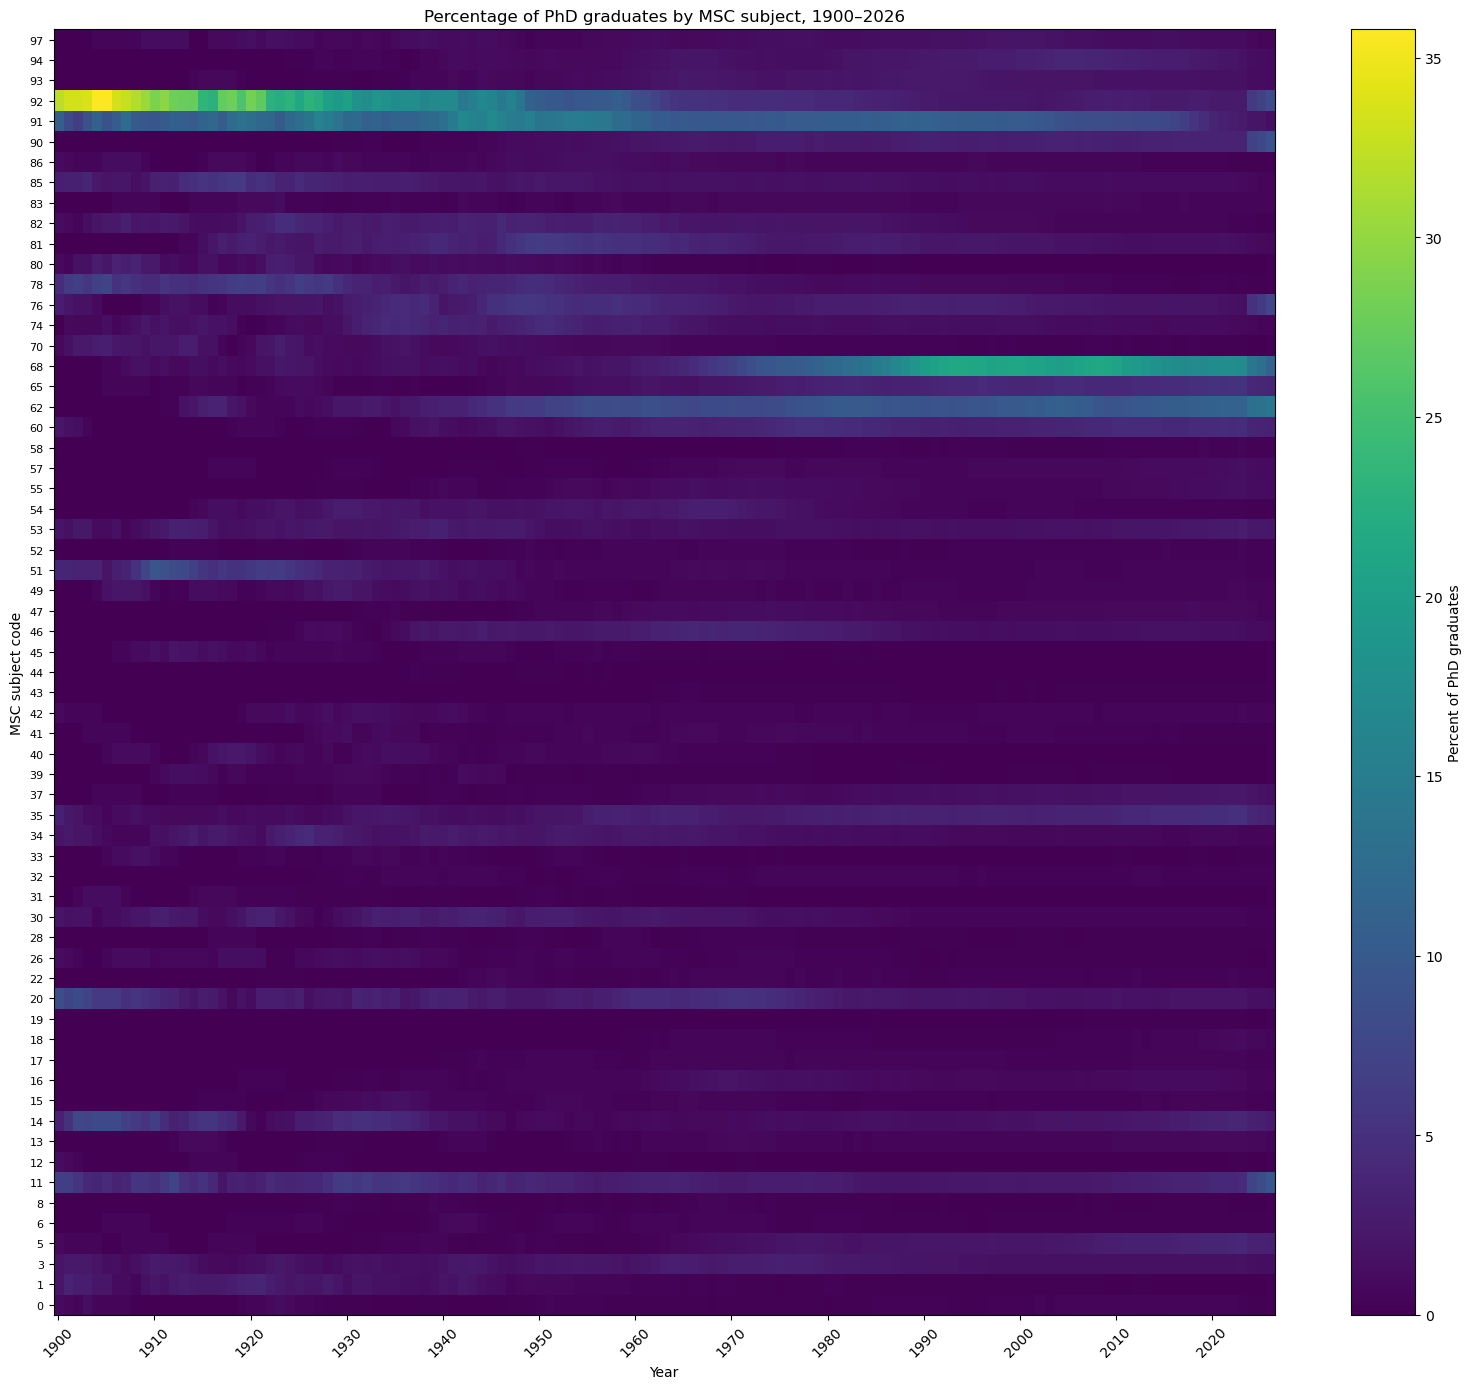

In [22]:
share_smooth = share.T.rolling(5, center=True, min_periods=1).mean().T

fig, ax = plt.subplots(figsize=(16, 14))

im = ax.imshow(
    share_smooth,
    aspect="auto",
    origin="lower",
    interpolation="nearest"
)

ax.set_xticks(np.arange(0, len(years), 10))
ax.set_xticklabels(years[::10], rotation=45)

ax.set_yticks(np.arange(len(codes)))
ax.set_yticklabels([str(int(c)) for c in codes], fontsize=8)

ax.set_xlabel("Year")
ax.set_ylabel("MSC subject code")
ax.set_title("Percentage of PhD graduates by MSC subject, 1900–2026")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Percent of PhD graduates")

plt.tight_layout()
plt.show()

### For Pure math (subject code $\le$ 60)

In [42]:
#pure math count
len(nodes[(nodes["subject_code"]<61)&(nodes["subject_code"].notna())&(nodes["year"].between(1900, 2026))])

87136

In [76]:
years = np.arange(1900, 2027)

valid_pure = nodes[
    (nodes["subject_code"].notna()) &
    (nodes["subject_code"]<61) &
    (nodes["year"].between(1900, 2026))
].copy()

valid_pure["year"] = valid_pure["year"].astype(int)

codes_pure = np.sort(valid_pure["subject_code"].unique())

counts = pd.crosstab(
    valid_pure["subject_code"],
    valid_pure["year"]
).reindex(index=codes_pure, columns=years, fill_value=0)

year_totals = counts.sum(axis=0).replace(0, np.nan)

share = counts.div(year_totals, axis=1) * 100


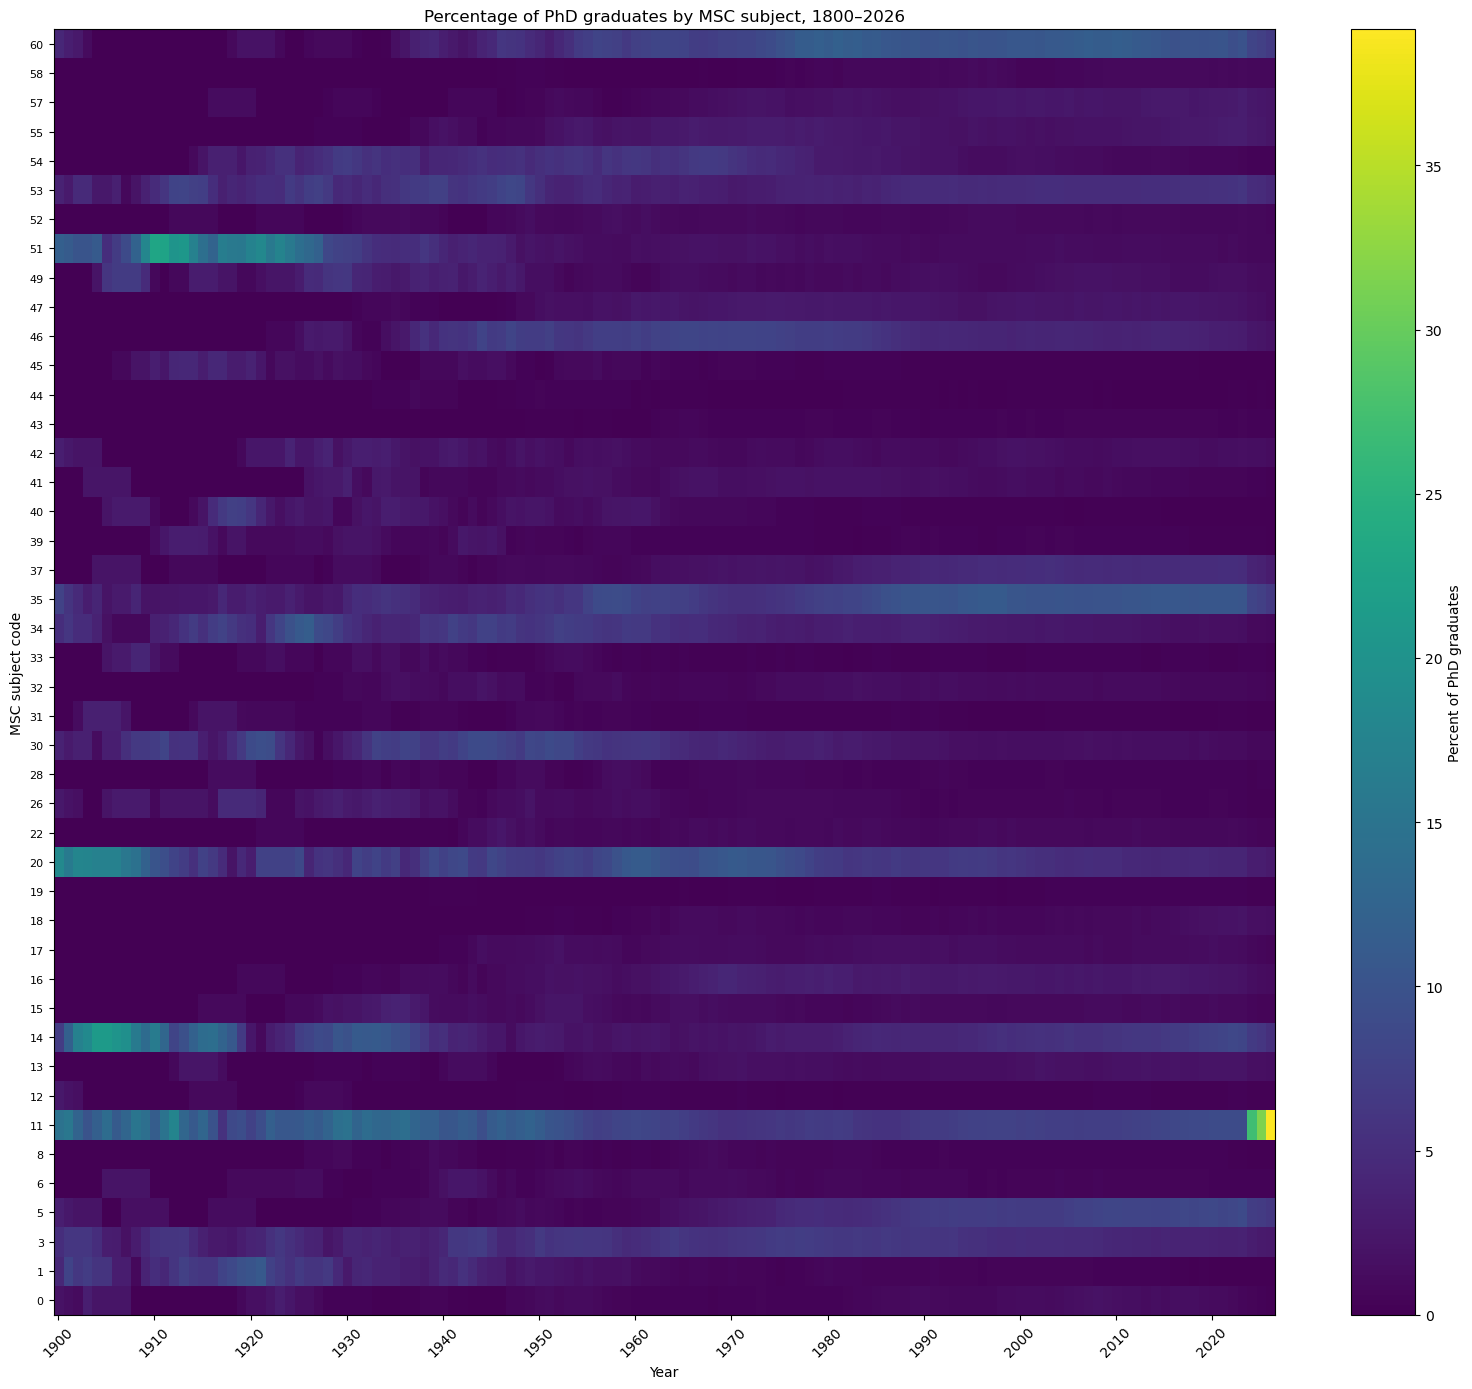

In [77]:
share_smooth = share.T.rolling(5, center=True, min_periods=1).mean().T

fig, ax = plt.subplots(figsize=(16, 14))

im = ax.imshow(
    share_smooth,
    aspect="auto",
    origin="lower",
    interpolation="nearest"
)

ax.set_xticks(np.arange(0, len(years), 10))
ax.set_xticklabels(years[::10], rotation=45)

ax.set_yticks(np.arange(len(codes_pure)))
ax.set_yticklabels([str(int(c)) for c in codes_pure], fontsize=8)

ax.set_xlabel("Year")
ax.set_ylabel("MSC subject code")
ax.set_title("Percentage of PhD graduates by MSC subject, 1800–2026")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Percent of PhD graduates")

plt.tight_layout()
plt.show()

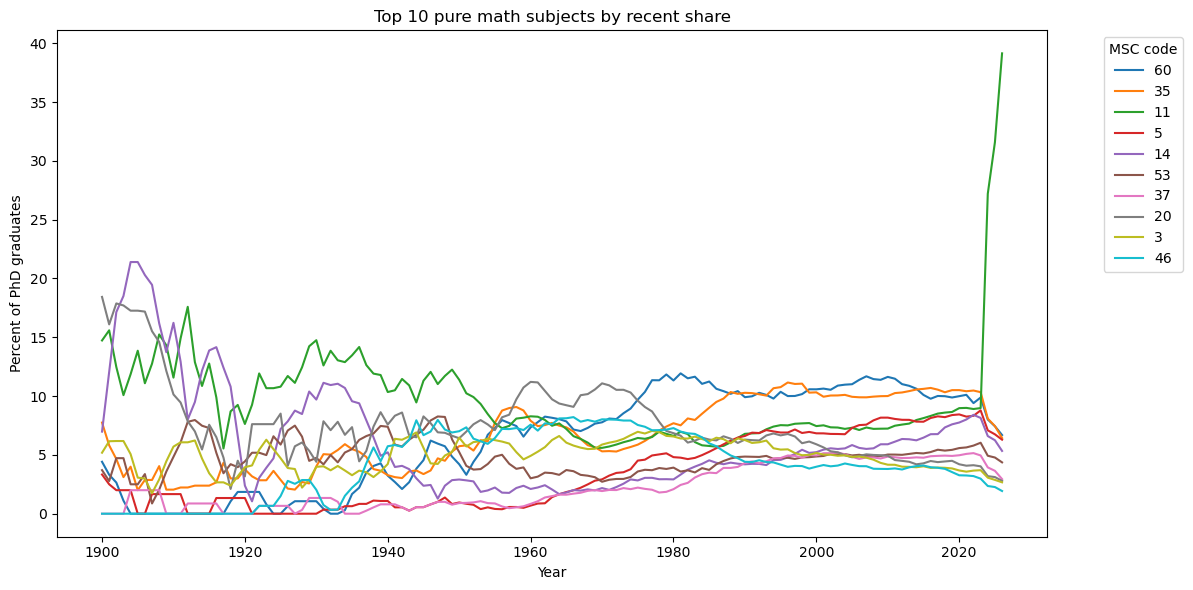

In [79]:
top10 = share.loc[:, 2000:2025].mean(axis=1).sort_values(ascending=False).head(10).index

share_top10 = share.loc[top10].T
share_top10_smooth = share_top10.rolling(5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 6))

for code_pure in top10:
    ax.plot(
        share_top10_smooth.index,
        share_top10_smooth[code_pure],
        label=str(int(code_pure))
    )

ax.set_xlabel("Year")
ax.set_ylabel("Percent of PhD graduates")
ax.set_title("Top 10 pure math subjects by recent share")
ax.legend(title="MSC code", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

### compare with original data

In [80]:
#create DataFrame with subject_code given from mgp
nodes_0=nodes[(~nodes['subject_code'].isna())&(nodes['predicted_subject_code'].isna())]
len(nodes_0)

202492

In [ ]:
years = np.arange(1900, 2027)

valid_0_pure = nodes_0[
    (nodes_0["subject_code"].notna()) &
    (nodes_0["subject_code"]<61) &
    (nodes_0["year"].between(1900, 2026))
].copy()


valid_0_pure["year"] = valid_0_pure["year"].astype(int)

codes_0_pure = np.sort(valid_0_pure["subject_code"].unique())

counts = pd.crosstab(
    valid_0_pure["subject_code"],
    valid_0_pure["year"]
).reindex(index=codes_0_pure, columns=years, fill_value=0)

year_totals = counts.sum(axis=0).replace(0, np.nan)

share = counts.div(year_totals, axis=1) * 100

TypeError: only length-1 arrays can be converted to Python scalars

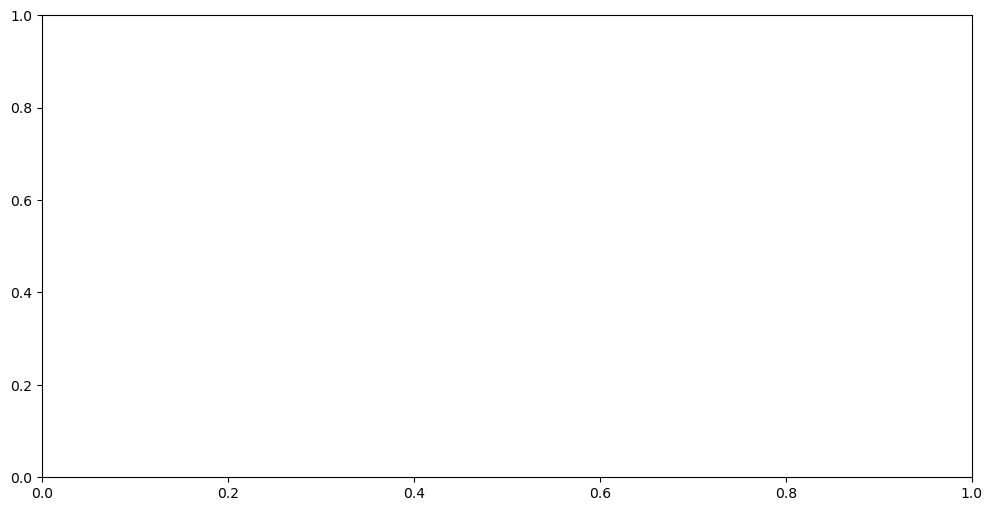

In [85]:
top10 = share.loc[:, 2000:2025].mean(axis=1).sort_values(ascending=False).head(10).index

share_top10 = share.loc[top10].T
share_top10_smooth = share_top10.rolling(5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(12, 6))

for code in top10:
    ax.plot(
        share_top10_smooth.index,
        share_top10_smooth[code],
        label=str(int(codes))
    )

ax.set_xlabel("Year")
ax.set_ylabel("Percent of PhD graduates")
ax.set_title("Top 10 pure math subjects by recent share")
ax.legend(title="MSC code", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [86]:
top10

Index([60.0, 35.0, 5.0, 11.0, 14.0, 53.0, 37.0, 20.0, 3.0, 46.0], dtype='float64', name='subject_code')

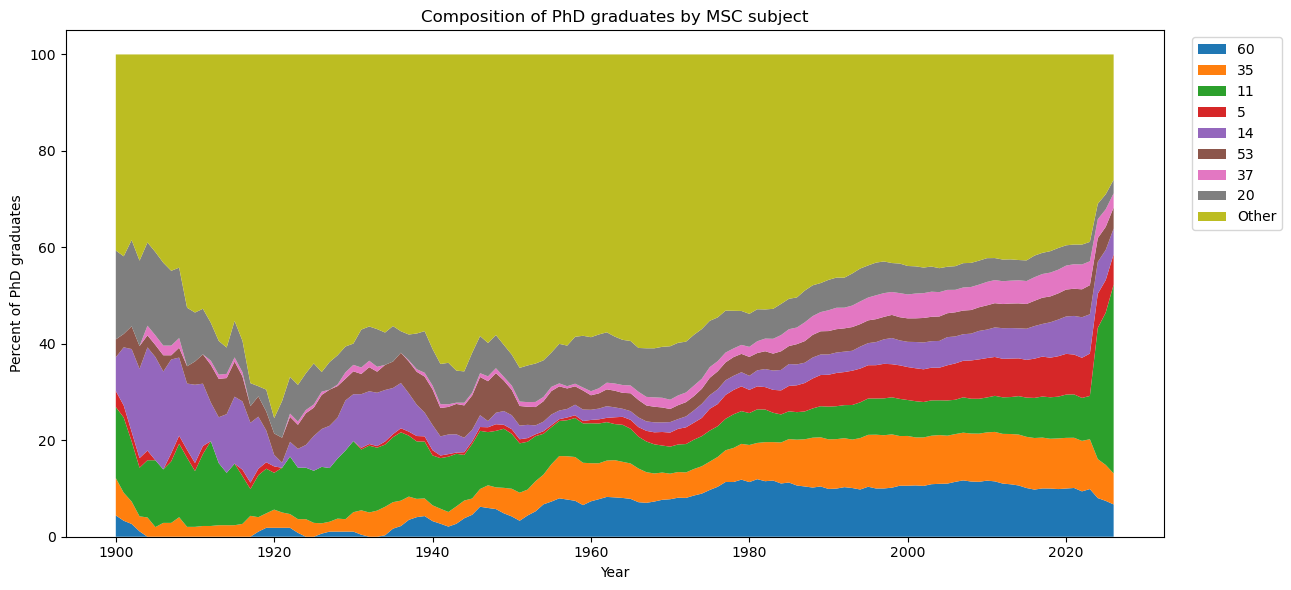

In [55]:
top8 = share.loc[:, 2000:2025].mean(axis=1).sort_values(ascending=False).head(8).index

area_data = share.loc[top8].T.copy()
area_data["Other"] = 100 - area_data.sum(axis=1)

area_data_smooth = area_data.rolling(5, center=True, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(13, 6))

ax.stackplot(
    area_data_smooth.index,
    area_data_smooth.T,
    labels=[str(int(c)) if c != "Other" else "Other" for c in area_data_smooth.columns]
)

ax.set_xlabel("Year")
ax.set_ylabel("Percent of PhD graduates")
ax.set_title("Composition of PhD graduates by MSC subject")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))

plt.tight_layout()
plt.show()

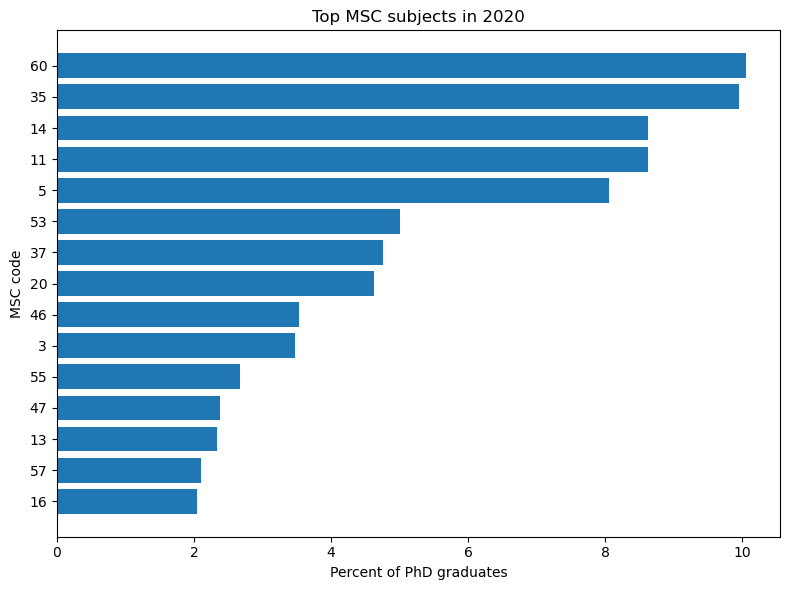

In [56]:
year = 2020

top_year = share[year].sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 6))

ax.barh([str(int(c)) for c in top_year.index[::-1]], top_year.values[::-1])

ax.set_xlabel("Percent of PhD graduates")
ax.set_ylabel("MSC code")
ax.set_title(f"Top MSC subjects in {year}")

plt.tight_layout()
plt.show()

In [57]:
#count the subject total (including predicted with confidence>5.5)
C=np.zeros((63,2))
for i in range(63):
    C[i,0]=codes[i]
    C[i,1]=len(nodes[nodes['subject_code']==codes[i]])

IndexError: index 2 is out of bounds for axis 0 with size 2

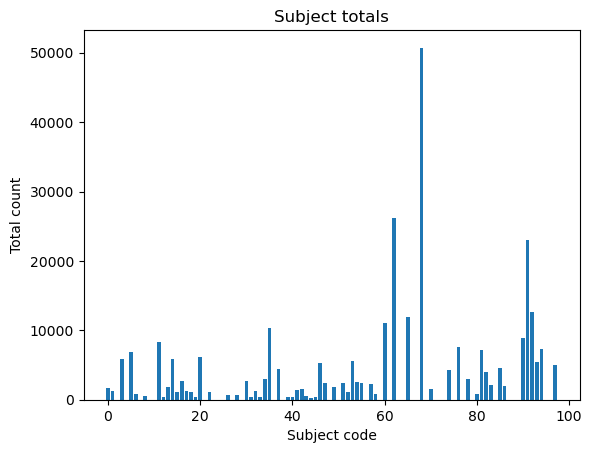

In [ ]:
plt.bar(C[:, 0], C[:, 1])
plt.xlabel("Subject code")
plt.ylabel("Total count")
plt.title("Subject totals")
plt.show()

In [ ]:
#count the predicted subject total, third column is the ratio
D=np.zeros((63,3))
for i in range(63):
    D[i,0]=codes[i]
    D[i,1]=len(nodes[nodes['predicted_subject_code']==codes[i]])
    D[i,2]=D[i,1]/C[i,1]

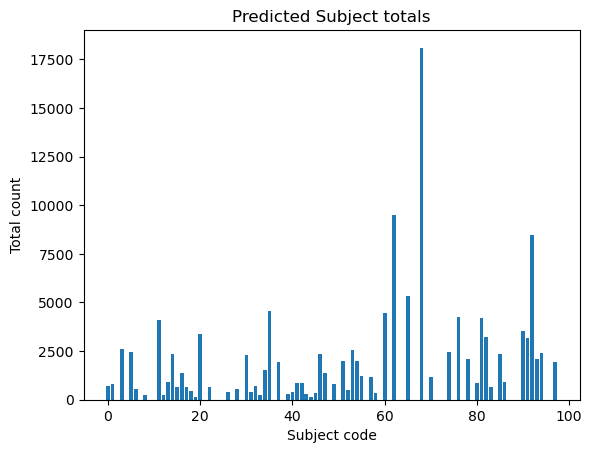

In [ ]:
plt.bar(D[:, 0], D[:, 1])
plt.xlabel("Subject code")
plt.ylabel("Total count")
plt.title("Predicted Subject totals")
plt.show()

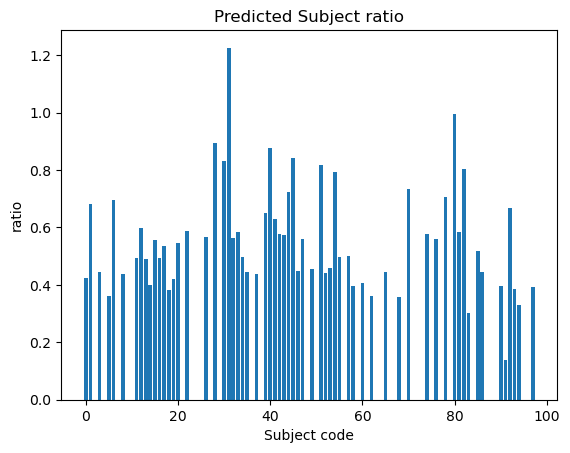

In [ ]:
plt.bar(D[:, 0], D[:, 2])
plt.xlabel("Subject code")
plt.ylabel("ratio")
plt.title("Predicted Subject ratio")
plt.show()

In [ ]:
#sanity check
W=[]
for i in range(len(nodes)):
    row = nodes.iloc[i]
    if pd.isna(row["subject_code"]):
        if (not pd.isna(row['predicted_subject_code']))& (row['subject_prediction_confidence']>=0.55):
            W.append(row['id'])
    #if not pd.isna(row["subject_code"]):
    #    if (row['predicted_subject_code']!=row['subject_code']) & (pd.isna(row['subject_prediction_confidence'])):
    #       W.append(row['id'])
print(W)

[np.int64(218952)]


In [ ]:
#count the predicted subject with confidence>5.5
E=np.zeros((63,4))
for i in range(63):
    E[i,0]=codes[i]
    E[i,1]=len(nodes[(nodes['subject_code']==codes[i])&(nodes['subject_prediction_confidence']>0.55)])
    E[i,2]=E[i,1]/(C[i,1]-E[i,1])
    E[i,3]=E[i,1]/C[i,1]

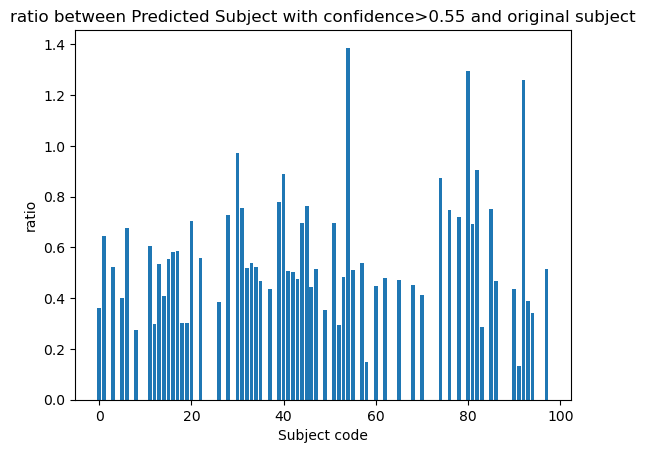

In [ ]:
plt.bar(E[:, 0], E[:, 2])
plt.xlabel("Subject code")
plt.ylabel("ratio")
plt.title("ratio between Predicted Subject with confidence>0.55 and original subject")
plt.show()

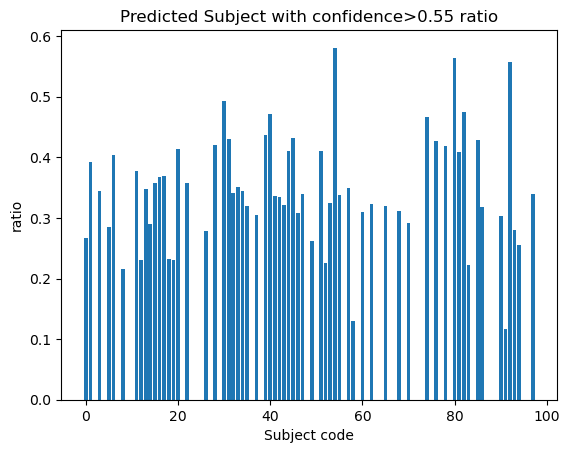

In [ ]:
plt.bar(E[:, 0], E[:, 3])
plt.xlabel("Subject code")
plt.ylabel("ratio")
plt.title("Predicted Subject with confidence>0.55 ratio")
plt.show()